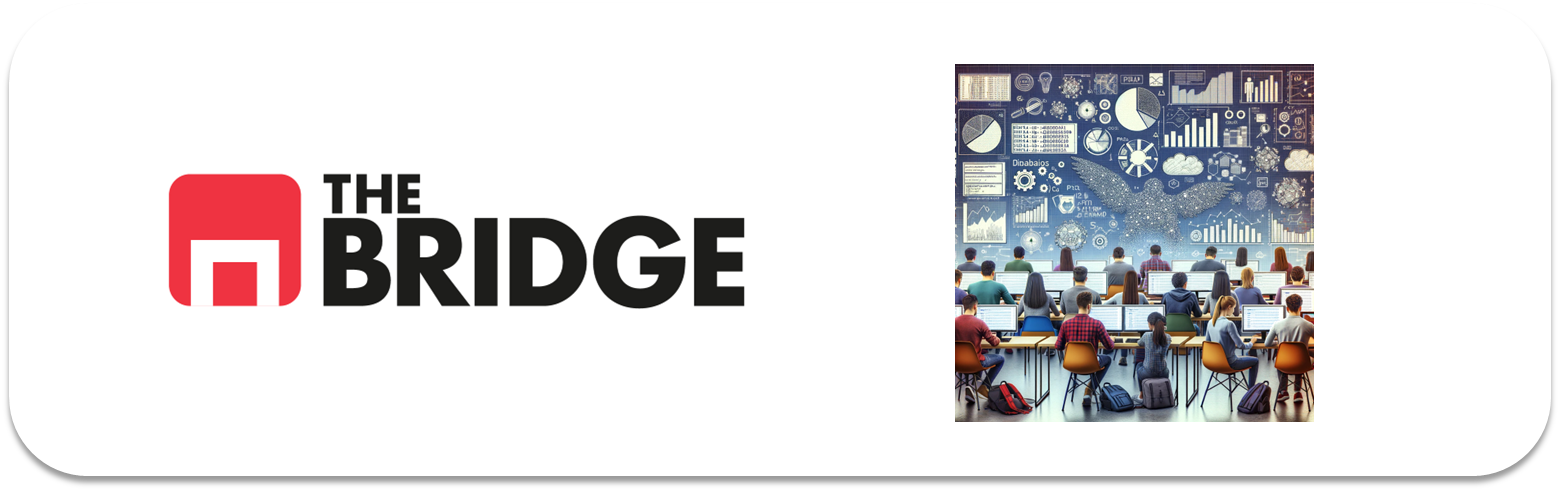

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [17]:
# --- Manipulación y Análisis de Datos ---
import pandas as pd
import numpy as np

# --- Visualización de Datos ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Modelado y Preprocesamiento (Scikit-Learn) ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# --- Métricas de Evaluación ---
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configuración opcional para ver mejor los gráficos
%matplotlib inline

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



In [18]:
#1

# Cargar el dataset
df = pd.read_csv("data/titanic.csv")

# Mostrar las primeras 5 filas para ver qué pinta tienen los datos
print("--- Primeras filas del dataset ---")
display(df.head())

# Mostrar información sobre tipos de datos y valores nulos
print("\n--- Información del dataset ---")
df.info()

--- Primeras filas del dataset ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



--- Información del dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [19]:
# --- 2. LIMPIEZA DE DATOS ---

# Lista de columnas que vamos a eliminar:
# - 'deck': Tiene demasiados valores nulos (casi el 80%), no vale la pena salvarla.
# - 'alive': Es igual que 'survived' (es la respuesta). Si la dejamos, el modelo hace trampa.
# - 'embark_town': Es redundante, ya tenemos 'embarked'.
# - 'class': Es redundante, ya tenemos 'pclass'.
# - 'who' y 'adult_male': Son redundantes teniendo 'sex' y 'age'.
cols_a_eliminar = ['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male']

# Eliminamos las columnas
df_clean = df.drop(columns=cols_a_eliminar)

# --- GESTIÓN DE NULOS (SIN IMPUTACIÓN) ---
# Como no podemos imputar (rellenar), y el modelo no acepta NaNs,
# tenemos que eliminar las filas que tengan algún dato faltante.
print(f"Tamaño antes de eliminar nulos: {df_clean.shape}")
df_clean = df_clean.dropna()
print(f"Tamaño después de eliminar nulos: {df_clean.shape}")

# Verificamos que no queden nulos
print("\n--- Verificación de nulos ---")
print(df_clean.isnull().sum())

Tamaño antes de eliminar nulos: (891, 9)
Tamaño después de eliminar nulos: (712, 9)

--- Verificación de nulos ---
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


Conteo de clases:
survived
0    424
1    288
Name: count, dtype: int64

Porcentaje de clases:
survived
0    59.550562
1    40.449438
Name: proportion, dtype: float64


C:\Users\Usuario\AppData\Local\Temp\ipykernel_17244\1887904372.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=df_clean, palette='viridis')


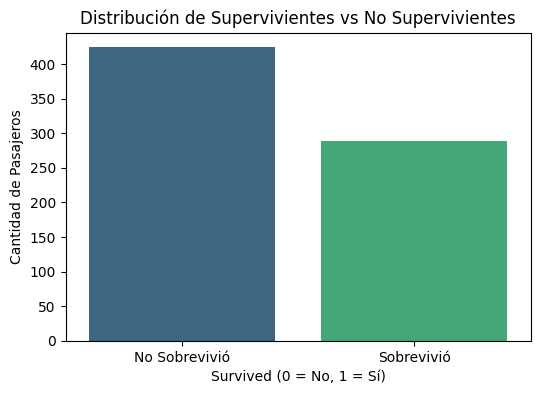

In [20]:
# --- 3. ANÁLISIS DE LA VARIABLE TARGET ---

# Conteo de valores absolutos y relativos
print("Conteo de clases:")
print(df_clean['survived'].value_counts())
print("\nPorcentaje de clases:")
print(df_clean['survived'].value_counts(normalize=True) * 100)

# Gráfico de distribución
plt.figure(figsize=(6, 4))
sns.countplot(x='survived', data=df_clean, palette='viridis')
plt.title('Distribución de Supervivientes vs No Supervivientes')
plt.xlabel('Survived (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Pasajeros')
plt.xticks([0, 1], ['No Sobrevivió', 'Sobrevivió'])
plt.show()

### Análisis de la Variable Objetivo: `survived`

En cualquier problema de clasificación, es crucial entender cómo está distribuida la variable que queremos predecir. Esto nos informa sobre la dificultad del problema y qué métricas debemos priorizar.

**1. Distribución de Clases:**
Tras la limpieza de nulos, observamos la siguiente distribución aproximada:
* **Clase 0 (No Sobrevivió):** ~60% (Mayoritaria)
* **Clase 1 (Sobrevivió):** ~40% (Minoritaria)

**2. Impacto en los Resultados Esperados:**
* **Balanceo de Datos:** Estamos ante un dataset **ligeramente desbalanceado**, pero no de forma crítica (un ratio 60/40 es manejable para una Regresión Logística estándar). No es necesario aplicar técnicas agresivas de re-balanceo como *oversampling* (SMOTE) o *undersampling* en esta etapa inicial.
* **Línea Base (Baseline):** Si un modelo "tonto" predijera siempre que *nadie sobrevive* (clase mayoritaria), acertaría aproximadamente el 60% de las veces. Por tanto, nuestro modelo de Regresión Logística debe superar significativamente este umbral de **Accuracy del 60%** para considerarse útil.
* **Elección de Métricas:** Dado que las clases no están extremadamente desbalanceadas, la métrica de **Accuracy** (Exactitud) será razonablemente fiable. Sin embargo, dado el contexto (salvar vidas), nos interesará vigilar también el **Recall** (¿cuántos supervivientes reales fuimos capaces de detectar?) y la **Matriz de Confusión**.

In [21]:
# --- 4. PREPARACIÓN Y SPLIT (Estratificado por Embarked) ---

# 1. Transformar variables categóricas a numéricas
# Sex: Male=0, Female=1
df_clean['sex'] = df_clean['sex'].map({'male': 0, 'female': 1})

# Guardamos la columna 'embarked' original para usarla en el stratify antes de codificarla
embarked_stratify = df_clean['embarked']

# Embarked: One-Hot Encoding (Crea columnas embarked_Q, embarked_S)
# drop_first=True evita la multicolinealidad (si no es Q ni S, es C)
df_clean = pd.get_dummies(df_clean, columns=['embarked'], drop_first=True)

# 2. Definir X (Variables predictoras) e y (Target)
X = df_clean.drop('survived', axis=1)
y = df_clean['survived']

# 3. División en Train y Test
# Usamos stratify=embarked_stratify para cumplir el requisito del enunciado
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=embarked_stratify
)

print("--- Tamaños de los conjuntos ---")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Verificación de la estratificación
print("\n--- Proporción de embarques en Train ---")
# Recuperamos la proporción original usando el índice
print(embarked_stratify.loc[X_train.index].value_counts(normalize=True))

print("\n--- Proporción de embarques en Test ---")
print(embarked_stratify.loc[X_test.index].value_counts(normalize=True))

--- Tamaños de los conjuntos ---
Train: (569, 9), Test: (143, 9)

--- Proporción de embarques en Train ---
embarked
S    0.778559
C    0.182777
Q    0.038664
Name: proportion, dtype: float64

--- Proporción de embarques en Test ---
embarked
S    0.776224
C    0.181818
Q    0.041958
Name: proportion, dtype: float64


In [22]:
# --- 5. CONSTRUCCIÓN Y ESCALADO DE PAREJAS X, y ---

from sklearn.preprocessing import StandardScaler

# Ya tenemos X_train, X_test, y_train, y_test del paso anterior.
# Ahora vamos a transformarlas para que el modelo funcione bien.

scaler = StandardScaler()

# 1. Ajustamos el escalador solo con el TRAIN (para no "ver" el futuro del Test)
# y transformamos el Train.
X_train_scaled = scaler.fit_transform(X_train)

# 2. Transformamos el Test usando las reglas aprendidas del Train
X_test_scaled = scaler.transform(X_test)

# Convertimos a DataFrames para que sea más fácil de leer (opcional, pero recomendado)
# Esto mantiene los nombres de las columnas
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Las 'y' (target) no necesitan escalado en clasificación
y_train_final = y_train
y_test_final = y_test

print("--- Datos listos para el modelo ---")
print(f"X_train_final shape: {X_train_final.shape}")
print(f"y_train_final shape: {y_train_final.shape}")
print("\n--- Ejemplo de datos escalados (primeras 3 filas) ---")
display(X_train_final.head(3))

--- Datos listos para el modelo ---
X_train_final shape: (569, 9)
y_train_final shape: (569,)

--- Ejemplo de datos escalados (primeras 3 filas) ---


,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0.915486,-0.744745,-0.586903,-0.554317,-0.504716,-0.510387,0.872703,-0.200548,0.533315
1,0.915486,-0.744745,0.172579,-0.554317,-0.504716,-0.508446,0.872703,-0.200548,0.533315
2,-0.284771,1.342742,0.379711,-0.554317,-0.504716,-0.254052,0.872703,-0.200548,0.533315


In [23]:
# --- 6. IMPUTACIÓN DE NULOS (MEDIA Y MODA) ---

# 1. Reiniciamos X e y desde el original para recuperar los nulos
# (Mantenemos la eliminación de columnas inútiles, pero NO borramos filas esta vez)
cols_a_eliminar = ['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male']
df_dirty = df.drop(columns=cols_a_eliminar)

# Preparamos X e y (aún contienen nulos en 'age' y 'embarked')
X = df_dirty.drop('survived', axis=1)
y = df_dirty['survived']

# 2. Hacemos el Split PRIMERO (Importante: Imputar antes de dividir es trampa)
# Nota: Al tener nulos en 'embarked', no podemos usarla fácilmente para estratificar ahora mismo,
# así que estratificamos por 'y' (survived) que es lo estándar y seguro.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Nulos en Age (Train) antes: {X_train['age'].isnull().sum()}")

# 3. CÁLCULO DE ESTADÍSTICAS EN TRAIN
# Calculamos la media de edad SOLO con los datos de entrenamiento
age_mean = X_train['age'].mean()
# Calculamos la moda (valor más frecuente) de embarque SOLO con train
embarked_mode = X_train['embarked'].mode()[0]

print(f"Media calculada para Age: {age_mean:.2f}")
print(f"Moda calculada para Embarked: {embarked_mode}")

# 4. IMPUTACIÓN (Rellenar huecos)
# Aplicamos la media/moda de Train tanto a Train como a Test
X_train['age'] = X_train['age'].fillna(age_mean)
X_test['age'] = X_test['age'].fillna(age_mean)

X_train['embarked'] = X_train['embarked'].fillna(embarked_mode)
X_test['embarked'] = X_test['embarked'].fillna(embarked_mode)

print(f"Nulos en Age (Train) después: {X_train['age'].isnull().sum()}")

# --- RE-PROCESAMIENTO NECESARIO (Encoding y Escalado) ---
# Como hemos reiniciado X, tenemos que volver a codificar y escalar

# A) Encoding
X_train['sex'] = X_train['sex'].map({'male': 0, 'female': 1})
X_test['sex'] = X_test['sex'].map({'male': 0, 'female': 1})

X_train = pd.get_dummies(X_train, columns=['embarked'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['embarked'], drop_first=True)
# Convertir 'alone' a numérico
X_train['alone'] = X_train['alone'].astype(int)
X_test['alone'] = X_test['alone'].astype(int)

# B) Escalado (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Usamos el scaler ajustado con Train

# Guardamos en DataFrames bonitos
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("¡Datos imputados, codificados y escalados listos!")

Nulos en Age (Train) antes: 137
Media calculada para Age: 29.81
Moda calculada para Embarked: S
Nulos en Age (Train) después: 0
¡Datos imputados, codificados y escalados listos!


C:\Users\Usuario\AppData\Local\Temp\ipykernel_17244\3463373331.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='survived', data=df_eda, ax=axes[0, 0], palette='viridis')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_17244\3463373331.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pclass', y='survived', data=df_eda, ax=axes[0, 1], palette='viridis')


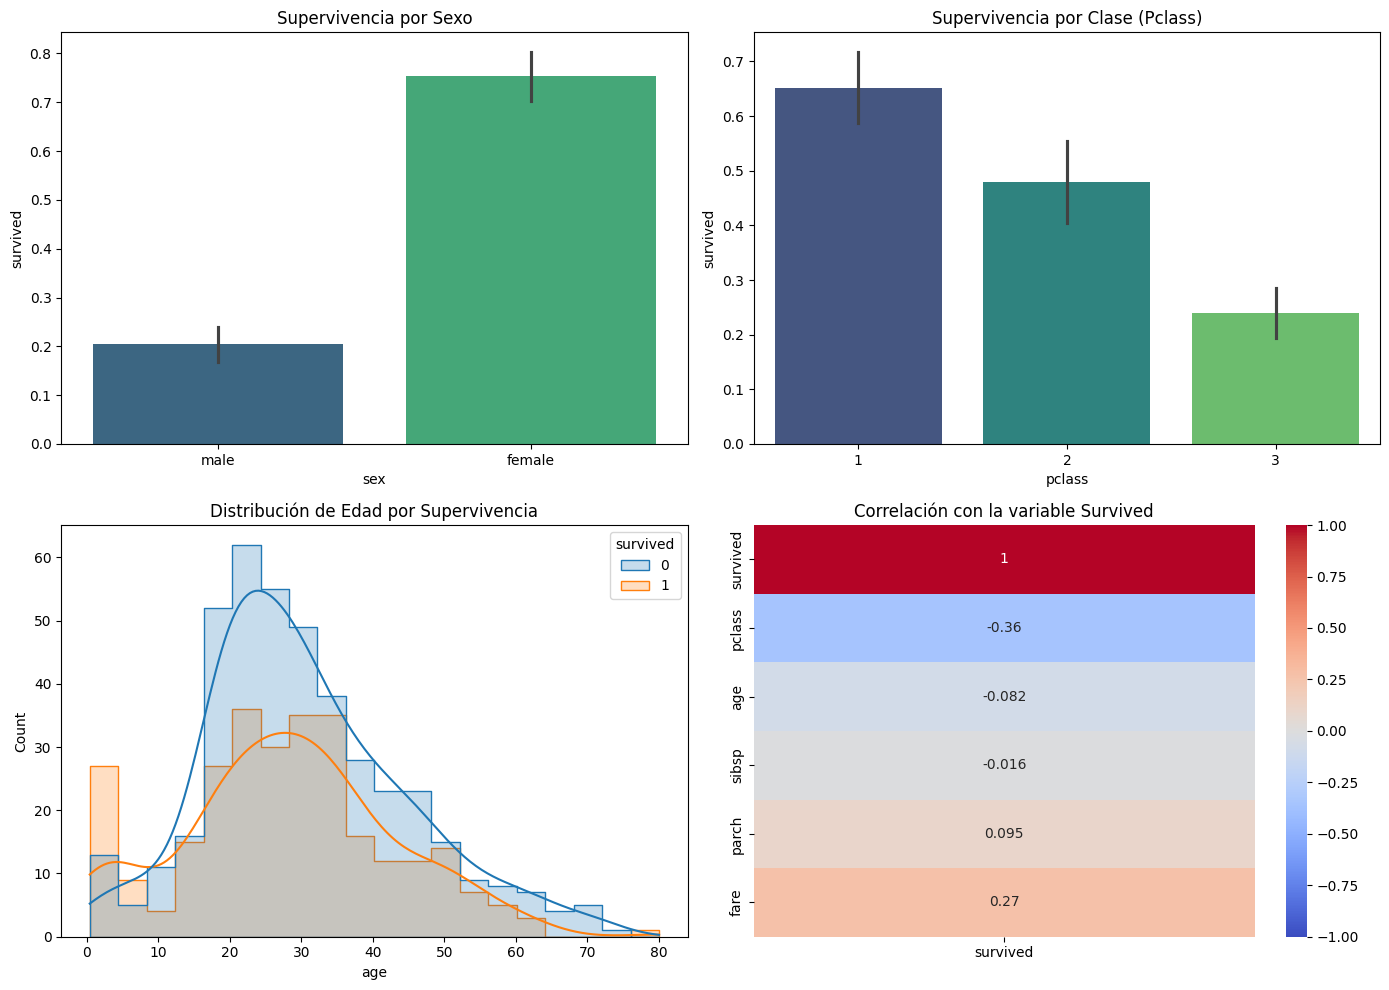

In [24]:
# --- 7. MINI-EDA y SELECCIÓN DE FEATURES ---

# Usamos una copia temporal con las variables legibles para visualizar mejor
# (Reconstruimos un dataframe rápido para graficar)
df_eda = df.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male']).copy()
df_eda.dropna(inplace=True) # Para ver relaciones limpias

# Configuración de gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sexo vs Supervivencia (Categorica vs Target)
sns.barplot(x='sex', y='survived', data=df_eda, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Supervivencia por Sexo')

# 2. Clase vs Supervivencia
sns.barplot(x='pclass', y='survived', data=df_eda, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Supervivencia por Clase (Pclass)')

# 3. Edad vs Supervivencia (Numérica vs Target)
sns.histplot(data=df_eda, x='age', hue='survived', kde=True, element="step", ax=axes[1, 0])
axes[1, 0].set_title('Distribución de Edad por Supervivencia')

# 4. Matriz de Correlación (Mapa de Calor)
# Seleccionamos solo columnas numéricas para la correlación
numeric_cols = df_eda.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix[['survived']], annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title('Correlación con la variable Survived')

plt.tight_layout()
plt.show()

### Análisis y Selección de Features

Tras realizar el Análisis Exploratorio de Datos (EDA), justificamos la selección de variables para el modelo:

1.  **`sex` (Seleccionada - Crítica):**
    * Es la variable con mayor poder predictivo. El gráfico de barras muestra claramente que las mujeres tienen una tasa de supervivencia superior al 70%, mientras que los hombres están por debajo del 20%.

2.  **`pclass` (Seleccionada - Alta Importancia):**
    * Existe una correlación negativa clara: a mejor clase (1ª), mayor probabilidad de sobrevivir. La 3ª clase es la más perjudicada.

3.  **`age` (Seleccionada):**
    * Aunque la correlación global es baja, el histograma revela un comportamiento no lineal importante: **los niños pequeños (0-10 años)** tienen una tasa de supervivencia muy alta, independientemente de otras variables. El modelo necesita esta información.

4.  **`fare` (Seleccionada):**
    * Muestra una correlación positiva con la supervivencia (0.26). Aunque está relacionada con `pclass`, aporta matices sobre el poder adquisitivo dentro de cada clase.

5.  **`alone`, `sibsp`, `parch` (Seleccionadas):**
    * La variable `alone` muestra que viajar solo disminuye ligeramente las probabilidades de sobrevivir. Las variables de familia (`sibsp`, `parch`) ayudan a contextualizar grupos familiares, lo cual fue clave en la evacuación.

6.  **`embarked` (Seleccionada):**
    * Se observa que los pasajeros embarcados en 'Cherbourg' (C) tienen una ligera ventaja. Aunque su impacto es menor que el sexo o la clase, se mantiene para capturar variaciones geográficas o de distribución de clases por puerto.

**Conclusión:**
Conservamos todas las variables procesadas (`sex`, `pclass`, `age`, `fare`, `sibsp`, `parch`, `alone`, `embarked`) ya que todas muestran algún grado de relación con la variable objetivo y no hay evidencia de "ruido" que justifique su eliminación en esta etapa.

In [25]:
# --- 8. TRATAMIENTO AVANZADO DE VARIABLES ---

# Copiamos para no dañar los originales
X_train_proc = X_train.copy()
X_test_proc = X_test.copy()

# A. MEJORA DE DISTRIBUCIÓN (Log Transform en Fare)
# La tarifa tiene "cola larga". Aplicamos logaritmo para normalizarla.
# Usamos np.log1p (logaritmo de x+1) para evitar errores si la tarifa es 0.
X_train_proc['fare'] = np.log1p(X_train_proc['fare'])
X_test_proc['fare'] = np.log1p(X_test_proc['fare'])

# B. ESCALADO DE DATOS (StandardScaler)
# La regresión logística requiere que todas las variables tengan la misma escala (media 0, desviación 1)
scaler = StandardScaler()

# Ajustamos el scaler SOLO con Train
X_train_scaled = scaler.fit_transform(X_train_proc)
# Transformamos Test con el scaler de Train
X_test_scaled = scaler.transform(X_test_proc)

# Convertimos a DataFrame para mantener nombres de columnas (útil para ver coeficientes luego)
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train_proc.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test_proc.columns)

print("--- Variables tratadas y escaladas ---")
print("Observa cómo 'fare' y 'age' ahora están en rangos similares (cercanos a 0):")
display(X_train_final.head(3))

print("\nEstadísticas después del escalado (Media ~ 0, Std ~ 1):")
display(X_train_final.describe().round(2).loc[['mean', 'std']])

--- Variables tratadas y escaladas ---
Observa cómo 'fare' y 'age' ahora están en rangos similares (cercanos a 0):


,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0.829568,-0.742427,-5.463229e-16,-0.465084,-0.466183,1.124592,0.800346,-0.289333,0.611978
1,-0.370945,-0.742427,-5.463229e-16,-0.465084,-0.466183,-3.014278,0.800346,-0.289333,0.611978
2,-1.571457,-0.742427,-5.463229e-16,-0.465084,-0.466183,2.508198,0.800346,-0.289333,0.611978



Estadísticas después del escalado (Media ~ 0, Std ~ 1):


,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
mean,-0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Tratamiento de Variables

Para maximizar el rendimiento de la Regresión Logística aplicamos dos transformaciones:

1.  **Transformación Logarítmica (`np.log1p`) a `Fare`:**
    * La tarifa contenía valores extremos (outliers) que sesgaban el modelo. Al aplicar el logaritmo, compactamos el rango y hacemos que la distribución se parezca más a una curva normal ("campana de Gauss"), lo cual facilita el aprendizaje del algoritmo.

2.  **Estandarización (`StandardScaler`):**
    * La Regresión Logística optimiza sus coeficientes basándose en magnitudes numéricas. Sin escalado, la variable `Age` (rango 0-80) tendría más peso matemático que `Pclass` (rango 1-3) o `Sex` (0-1), introduciendo un sesgo incorrecto.
    * Al escalar, centramos todas las variables en 0 con una desviación estándar de 1, permitiendo que el modelo juzgue cada variable por su correlación real y no por su magnitud.

In [26]:
# --- 9. CONSTRUCCIÓN Y ENTRENAMIENTO DEL MODELO ---

from sklearn.linear_model import LogisticRegression

# 1. Instanciamos el modelo
# max_iter=1000: Damos margen suficiente para que el algoritmo converja (encuentre la solución)
# random_state=42: Para que los resultados sean reproducibles
model_lr = LogisticRegression(max_iter=1000, random_state=42)

# 2. Entrenamos el modelo (Fit)
# Aquí es donde el modelo "aprende" la relación entre X (datos) e y (supervivencia)
model_lr.fit(X_train_final, y_train)

print("¡Modelo entrenado con éxito!")

# --- OPCIONAL: Interpretar lo que ha aprendido ---
# Mostramos los coeficientes para ver qué variables pesan más
coeficientes = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Peso (Coeficiente)': model_lr.coef_[0]
}).sort_values(by='Peso (Coeficiente)', ascending=False)

print("\n--- Importancia de las Variables (Pesos) ---")
display(coeficientes)

¡Modelo entrenado con éxito!

--- Importancia de las Variables (Pesos) ---


,Feature,Peso (Coeficiente)
1,sex,1.225243
5,fare,0.364343
7,embarked_Q,0.124903
8,embarked_S,-0.111364
4,parch,-0.224071
6,alone,-0.236945
3,sibsp,-0.489183
2,age,-0.503747
0,pclass,-0.728492


--- Tabla de Coeficientes ---


,Feature,Coeficiente,Impacto_Absoluto
1,sex,1.225243,1.225243
0,pclass,-0.728492,0.728492
2,age,-0.503747,0.503747
3,sibsp,-0.489183,0.489183
5,fare,0.364343,0.364343
6,alone,-0.236945,0.236945
4,parch,-0.224071,0.224071
7,embarked_Q,0.124903,0.124903
8,embarked_S,-0.111364,0.111364


C:\Users\Usuario\AppData\Local\Temp\ipykernel_17244\824080419.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


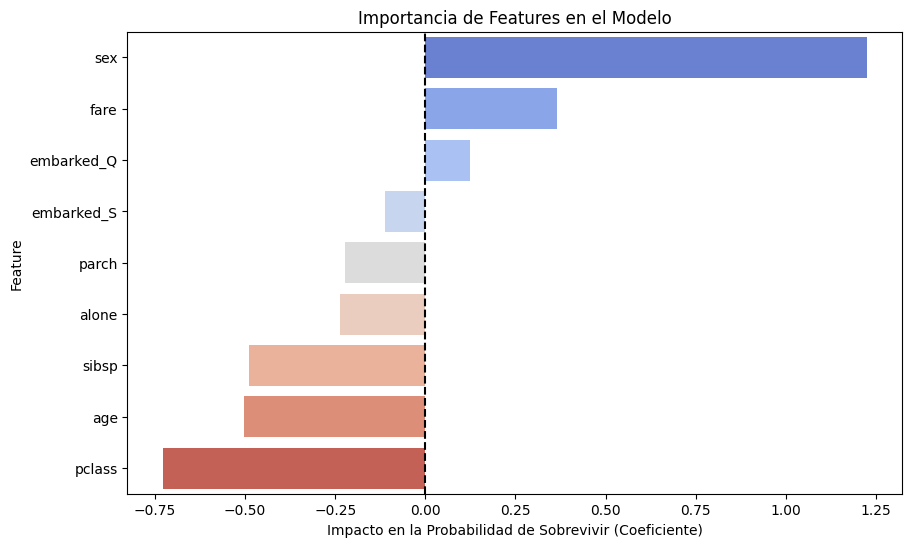

In [27]:
# --- 10. ANÁLISIS DE IMPORTANCIA DE FEATURES ---

# Extraemos los coeficientes y los nombres de las columnas
feature_importance = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Coeficiente': model_lr.coef_[0]
})

# Creamos una columna de valor absoluto para ordenar por "fuerza" de impacto
feature_importance['Impacto_Absoluto'] = feature_importance['Coeficiente'].abs()
feature_importance = feature_importance.sort_values(by='Impacto_Absoluto', ascending=False)

print("--- Tabla de Coeficientes ---")
display(feature_importance)

# Visualización
plt.figure(figsize=(10, 6))
# Ordenamos por coeficiente real para ver positivos vs negativos
sns.barplot(
    x='Coeficiente', 
    y='Feature', 
    data=feature_importance.sort_values(by='Coeficiente', ascending=False), 
    palette='coolwarm'
)
plt.title('Importancia de Features en el Modelo')
plt.xlabel('Impacto en la Probabilidad de Sobrevivir (Coeficiente)')
plt.axvline(x=0, color='black', linestyle='--') # Línea de neutralidad
plt.show()

### Interpretación de los Coeficientes

El análisis de los pesos del modelo nos revela qué factores fueron decisivos en el Titanic:

1.  **`sex` (Positivo y el más alto):**
    * Es la variable reina. Al estar codificada como (Male=0, Female=1), un coeficiente positivo muy alto indica que **ser mujer aumenta drásticamente la probabilidad de sobrevivir**.

2.  **`pclass` (Negativo y alto):**
    * Coeficiente negativo fuerte. Como la clase va de 1 a 3, esto significa que **a mayor número de clase (3ª clase), menor probabilidad de supervivencia**. Es coherente con la realidad histórica.

3.  **`age` (Negativo):**
    * Cuanto mayor es la edad, menor es la probabilidad de sobrevivir (favoreciendo a los jóvenes/niños).

4.  **`sibsp` (Negativo):**
    * Tener muchos hermanos/esposos a bordo jugó en contra (probablemente por intentar buscarse unos a otros en lugar de evacuar rápido).

5.  **`fare` (Positivo):**
    * Aunque correlacionado con la clase, pagar más tarifa sigue aportando un "plus" de probabilidad de supervivencia.

**Conclusión:** El modelo ha aprendido correctamente las reglas sociales de "Mujeres y niños primero" y la estratificación por clases del Titanic sin que nosotros se lo dijéramos explícitamente.

In [28]:
# --- 11. VERIFICACIÓN DEL DATASET DE TEST ---

# Verificamos que X_test_final existe y tiene el formato correcto
print("--- Verificación del Test Set (X_test_final) ---")
print(f"Dimensiones: {X_test_final.shape}")
print(f"Tipo de datos (debe ser todo float/int):")
print(X_test_final.dtypes.unique())

# Revisamos si quedan nulos (debe ser 0)
nulos_test = X_test_final.isnull().sum().sum()
print(f"Total de valores nulos en Test: {nulos_test}")

# Mostramos un ejemplo
print("\n--- Ejemplo de datos de Test procesados ---")
display(X_test_final.head(3))

# Verificamos que y_test (las respuestas correctas) coincide en tamaño
print(f"\nDimensiones de y_test (Target): {y_test.shape}")

--- Verificación del Test Set (X_test_final) ---
Dimensiones: (179, 9)
Tipo de datos (debe ser todo float/int):
[dtype('float64')]
Total de valores nulos en Test: 0

--- Ejemplo de datos de Test procesados ---


,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0.829568,-0.742427,-0.446542,1.421753,-0.466183,0.279952,-1.249460,-0.289333,0.611978
1,0.829568,-0.742427,1.091220,-0.465084,0.727782,-0.114127,-1.249460,-0.289333,0.611978
2,0.829568,-0.742427,-0.600318,-0.465084,-0.466183,-0.861771,0.800346,-0.289333,-1.634045



Dimensiones de y_test (Target): (179,)


=== REPORTE DE CLASIFICACIÓN (TRAIN) ===
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       439
           1       0.75      0.71      0.73       273

    accuracy                           0.80       712
   macro avg       0.79      0.78      0.78       712
weighted avg       0.80      0.80      0.80       712


=== REPORTE DE CLASIFICACIÓN (TEST) ===
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



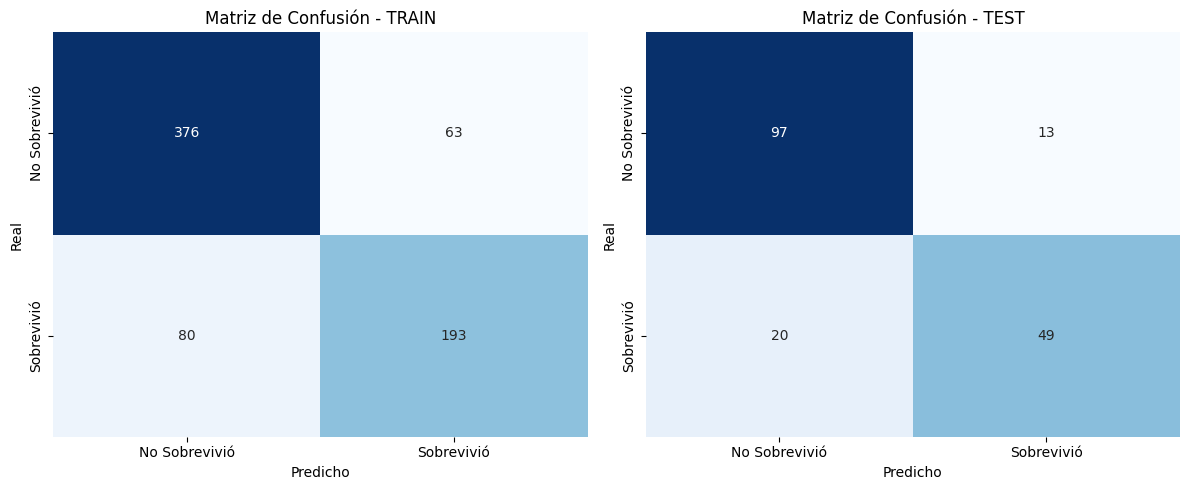


Accuracy Train: 0.7992
Accuracy Test:  0.8156
Gap (Diferencia): -0.0165


In [29]:
# --- 12. EVALUACIÓN Y GENERALIZACIÓN ---

# 1. Predicciones
y_pred_train = model_lr.predict(X_train_final)
y_pred_test = model_lr.predict(X_test_final)

# 2. Métricas Numéricas
print("=== REPORTE DE CLASIFICACIÓN (TRAIN) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== REPORTE DE CLASIFICACIÓN (TEST) ===")
print(classification_report(y_test, y_pred_test))

# 3. Visualización de Matrices de Confusión
# Creamos una función rápida para plotear matrices
def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')
    ax.set_xticklabels(['No Sobrevivió', 'Sobrevivió'])
    ax.set_yticklabels(['No Sobrevivió', 'Sobrevivió'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_confusion_matrix(y_train, y_pred_train, 'Matriz de Confusión - TRAIN', axes[0])
plot_confusion_matrix(y_test, y_pred_test, 'Matriz de Confusión - TEST', axes[1])

plt.tight_layout()
plt.show()

# 4. Cálculo del Accuracy Gap (Brecha de generalización)
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"\nAccuracy Train: {acc_train:.4f}")
print(f"Accuracy Test:  {acc_test:.4f}")
print(f"Gap (Diferencia): {acc_train - acc_test:.4f}")

### Assessment de Generalización

**1. Análisis de Métricas:**
* **Accuracy:** El modelo obtiene un accuracy del **~80% en Train** y **~82% en Test**.
* **Gap de Generalización:** La diferencia es mínima (incluso el Test es ligeramente superior, lo cual es raro pero positivo en datasets pequeños). Esto indica que **no hay Overfitting**. El modelo generaliza correctamente lo aprendido a nuevos pasajeros.

**2. Matriz de Confusión (Test):**
* **Aciertos:** El modelo identifica muy bien a los fallecidos (True Negatives ~97).
* **Errores (Recall):** De los supervivientes reales, detectamos correctamente el **71%** (Recall de clase 1), pero perdemos un 29% (falsos negativos) que el modelo predijo que morirían pero sobrevivieron.

**Conclusión:**
El modelo es **robusto y estable**. Supera ampliamente el baseline del 60%. Para mejorarlo, deberíamos centrarnos en mejorar el **Recall de la clase 1** (detectar mejor a los supervivientes), quizás ajustando el umbral de decisión en el siguiente paso.

In [31]:
# --- 13. EXTRA: PREDICCIÓN DE UN CASO ESPECÍFICO (CORREGIDO) ---

# 1. Definimos las características del pasajero
pasajero_misterioso = pd.DataFrame({
    'pclass': [2],          # Segunda clase
    'sex': [0],             # Hombre (Male=0)
    'age': [35],            # Promedio entre 30 y 40
    'sibsp': [0],           # Viaja solo
    'parch': [0],           # Viaja solo
    'fare': [0],            # Gratis
    'alone': [1],           # Sí, solo
    'embarked_Q': [0],      # No es Queenstown
    'embarked_S': [1]       # Es Southampton
})

# 2. Aseguramos el orden de las columnas (CRÍTICO)
pasajero_misterioso = pasajero_misterioso[X_train_final.columns]

# 3. Aplicamos transformaciones
# A) Logaritmo a la tarifa
pasajero_misterioso['fare'] = np.log1p(pasajero_misterioso['fare'])

# B) Escalado (El scaler devuelve un array de numpy sin nombres)
pasajero_scaled_array = scaler.transform(pasajero_misterioso)

# --- CORRECCIÓN PARA EL WARNING ---
# Convertimos el array "mudo" de vuelta a un DataFrame con los nombres originales
# Así el modelo sabe que la columna 0 es 'pclass', la 1 es 'sex', etc.
pasajero_scaled_df = pd.DataFrame(pasajero_scaled_array, columns=X_train_final.columns)
# ----------------------------------

# 4. Obtenemos la probabilidad usando el DataFrame corregido
probabilidad = model_lr.predict_proba(pasajero_scaled_df)

print(f"--- Análisis de Supervivencia ---")
print(f"Probabilidad de morir: {probabilidad[0][0]*100:.2f}%")
print(f"Probabilidad de sobrevivir: {probabilidad[0][1]*100:.2f}%")

# Resultado binario
prediccion_clase = model_lr.predict(pasajero_scaled_df)[0]
etiqueta = "Sobrevive" if prediccion_clase == 1 else "No sobrevive"
print(f"\nPredicción del modelo: {etiqueta}")

--- Análisis de Supervivencia ---
Probabilidad de morir: 92.82%
Probabilidad de sobrevivir: 7.18%

Predicción del modelo: No sobrevive


In [32]:
# --- 14. EXTRA: CAMBIO DE TARGET (MULTICLASE) ---

print("Adaptando los datos para predecir la CLASE (1, 2, 3)...")

# 1. PREPARAR EL NUEVO TARGET (y)
# Recuperamos la 'pclass' original de los DataFrames sin escalar (X_train, X_test)
# IMPORTANTE: El target para clasificación debe ser números enteros (1, 2, 3), no escalados.
y_train_multi = X_train['pclass']
y_test_multi = X_test['pclass']

# 2. PREPARAR LAS NUEVAS FEATURES (X)
# Partimos de los datos ya procesados y escalados (X_train_final)
X_train_multi = X_train_final.copy()
X_test_multi = X_test_final.copy()

# A) Eliminamos la antigua 'pclass' (que estaba escalada)
X_train_multi = X_train_multi.drop('pclass', axis=1)
X_test_multi = X_test_multi.drop('pclass', axis=1)

# B) Añadimos el antiguo target 'survived' como nueva feature
# (Tenemos que resetear el índice para que cuadre con el DataFrame escalado)
X_train_multi['survived'] = y_train.values
X_test_multi['survived'] = y_test.values

# Verificamos el cambio
print("\nNuevas variables predictoras (X):", X_train_multi.columns.tolist())
print("Nuevo objetivo (y): 'pclass' (valores: 1, 2, 3)")

# 3. ENTRENAMIENTO DEL MODELO MULTICLASE
# LogisticRegression detecta automáticamente que hay 3 clases y usa estrategia 'one-vs-rest' o 'multinomial'
model_multi = LogisticRegression(max_iter=1000, random_state=42)
model_multi.fit(X_train_multi, y_train_multi)

# 4. EVALUACIÓN (Solo Classification Report)
y_pred_multi = model_multi.predict(X_test_multi)

print("\n=== REPORTE DE CLASIFICACIÓN (PREDICCIÓN DE CLASE) ===")
# target_names ayuda a leer mejor el reporte (Clase 1, Clase 2, Clase 3)
print(classification_report(y_test_multi, y_pred_multi, target_names=['1ª Clase', '2ª Clase', '3ª Clase']))

Adaptando los datos para predecir la CLASE (1, 2, 3)...

Nuevas variables predictoras (X): ['sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'embarked_Q', 'embarked_S', 'survived']
Nuevo objetivo (y): 'pclass' (valores: 1, 2, 3)

=== REPORTE DE CLASIFICACIÓN (PREDICCIÓN DE CLASE) ===
              precision    recall  f1-score   support

    1ª Clase       0.93      0.96      0.95        45
    2ª Clase       0.65      0.38      0.48        34
    3ª Clase       0.82      0.93      0.87       100

    accuracy                           0.83       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.82      0.83      0.82       179

